---
title: "Blog 04: Analysis of Pennsylvania Crash Data"
description: "placeholder"
author: "Daniel Park"
date: "2/25/2026"
categories:
  - car crashes
  - data stories
  - data visualization
---

Young people are often described as being more vulnerable on the road. Whether as drivers or cyclists, youth is frequently linked to inexperience, risk-taking behaviour, and higher crash involvement. Over the past five years, I have experienced both a cycling accident and a car accident, which made me question whether that reputation reflects reality or simply perception.

Insurance premiums are higher for younger drivers, licensing systems impose additional restrictions, and safety campaigns consistently target teenagers and young adults. Broader traffic statistics often suggest that drivers in their late teens and early twenties are overrepresented in crash data, particularly in more severe incidents. The implication is clear: being young appears to carry greater risk.

But does this pattern actually hold in Pennsylvania?

In this post, I analyse Pennsylvania crash data to compare young drivers and young cyclists with other age groups. By examining crash frequency and severity across demographics, I aim to determine whether the claim that young road users are statistically more at risk is supported by evidence, or whether the story is more nuanced than it seems.

In [4]:
import pandas as pd
import geopandas as gpd
import numpy as np
import camelot
import calendar
import re
import matplotlib.pyplot as plt

In [5]:
crash_data = pd.read_csv('data/PDOT_crash_data_2005_2024.csv', low_memory=False)

In [6]:
data_dictionary = pd.read_csv('data/data_dictionary.csv')

In [17]:
young_cols = [
    "DRIVER_COUNT_16YR",
    "DRIVER_COUNT_17YR",
    "DRIVER_COUNT_18YR",
    "DRIVER_COUNT_19YR",
    "DRIVER_COUNT_20YR"
]

crash_data["young_driver_count"] = crash_data[young_cols].sum(axis=1)

crash_data["young_driver_present"] = (
    crash_data["young_driver_count"] > 0
).astype(int)

age_totals = crash_data[young_cols].sum().sort_index()
age_totals

DRIVER_COUNT_16YR     8949
DRIVER_COUNT_17YR    25113
DRIVER_COUNT_18YR    29348
DRIVER_COUNT_19YR    30088
DRIVER_COUNT_20YR    30440
dtype: int64

In [19]:
crash_data.columns.tolist()

['CRN',
 'ARRIVAL_TM',
 'AUTOMOBILE_COUNT',
 'BELTED_DEATH_COUNT',
 'BELTED_SUSP_SERIOUS_INJ_COUNT',
 'BICYCLE_COUNT',
 'BICYCLE_DEATH_COUNT',
 'BICYCLE_SUSP_SERIOUS_INJ_COUNT',
 'BUS_COUNT',
 'CHLDPAS_DEATH_COUNT',
 'CHLDPAS_SUSP_SERIOUS_INJ_COUNT',
 'COLLISION_TYPE',
 'COMM_VEH_COUNT',
 'CONS_ZONE_SPD_LIM',
 'COUNTY',
 'CRASH_MONTH',
 'CRASH_YEAR',
 'DAY_OF_WEEK',
 'DEC_LATITUDE',
 'DEC_LONGITUDE',
 'DISPATCH_TM',
 'DISTRICT',
 'DRIVER_COUNT_16YR',
 'DRIVER_COUNT_17YR',
 'DRIVER_COUNT_18YR',
 'DRIVER_COUNT_19YR',
 'DRIVER_COUNT_20YR',
 'DRIVER_COUNT_50_64YR',
 'DRIVER_COUNT_65_74YR',
 'DRIVER_COUNT_75PLUS',
 'EST_HRS_CLOSED',
 'FATAL_COUNT',
 'HEAVY_TRUCK_COUNT',
 'HORSE_BUGGY_COUNT',
 'HOUR_OF_DAY',
 'ILLUMINATION',
 'INJURY_COUNT',
 'INTERSECTION_RELATED',
 'INTERSECT_TYPE',
 'LANE_CLOSED',
 'LATITUDE',
 'LN_CLOSE_DIR',
 'LOCATION_TYPE',
 'LONGITUDE',
 'MAX_SEVERITY_LEVEL',
 'MCYCLE_DEATH_COUNT',
 'MCYCLE_SUSP_SERIOUS_INJ_COUNT',
 'MOTORCYCLE_COUNT',
 'MUNICIPALITY',
 'NONMOTR_COUN

In [34]:
crash_year_month_counts = crash_data.groupby(['CRASH_YEAR','CRASH_MONTH'])['BICYCLE_COUNT'].sum().unstack()
crash_year_month_counts

CRASH_MONTH,1,2,3,4,5,6,7,8,9,10,11,12
CRASH_YEAR,,,,,,,,,,,,
2005,13,12,19,63,67,86,84,113,104,65,58,14
2006,19,20,30,53,93,84,101,82,77,76,37,29
2007,34,9,37,50,104,83,116,95,117,68,37,21
2008,19,20,40,50,63,106,90,95,87,47,51,38
2009,17,20,35,63,66,90,108,65,97,64,56,33
2010,25,10,42,83,89,97,106,101,97,81,46,14
2011,6,16,29,43,74,123,87,102,74,68,47,34
2012,19,30,65,63,89,85,94,69,74,61,34,35
2013,18,12,21,69,90,91,94,109,105,69,42,24


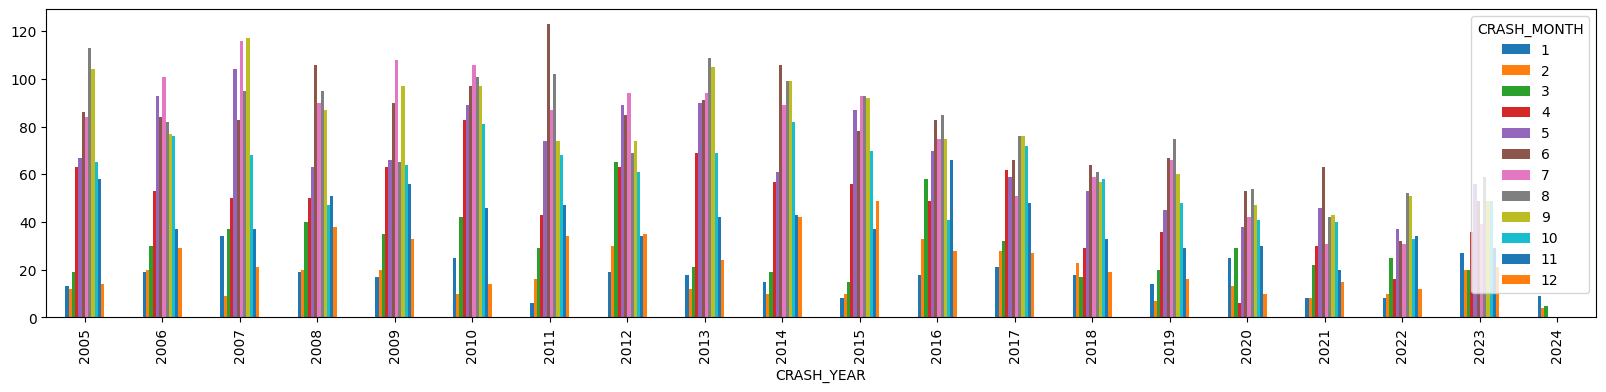

In [35]:
crash_year_month_counts.plot(kind='bar', figsize=(20,4))
plt.show()

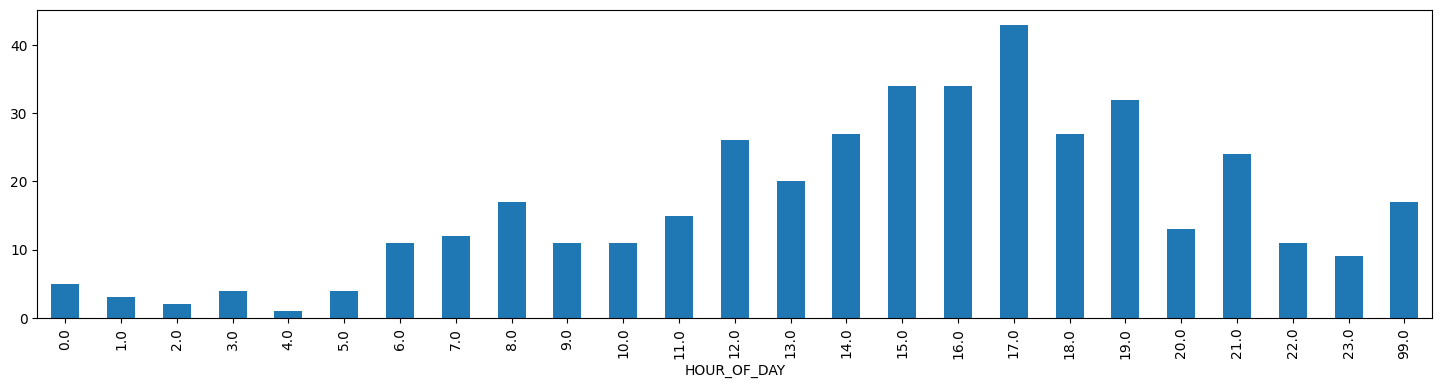

In [36]:
plt.figure(figsize=(18,4))
crash_data.groupby(['HOUR_OF_DAY'])['BICYCLE_COUNT'].sum().plot.bar()
plt.show()

* This plot shows bicycles involved in crashes grouped across all the data by the `HOUR_OF_DAY`


* Definitely seems like a _rush hour_ trend (`15-19`) that might be worth investigating.


* Notice also the number of `99` values. These probably indicate that the time of day was not recorded.

#### We'll finish off with a few other grouping and aggregating examples.


* Deaths of cyclists involved in crashes by year and month.

In [37]:
def format_xticklabels(plot):
    '''function to format (year, month) tick labels in a more readable format
    '''
    xticklabels = plot.get_xticklabels()
    new_labels = []
    for xtick in xticklabels:
        text = xtick.get_text()
        tmatch = re.match(r'\((20\d{2}), (\d{1,2})\)', text)
        mnum = int(tmatch.group(2))
        year = tmatch.group(1) if mnum==1 else ""
        mabbr = calendar.month_abbr[mnum]
        xtick.set_text(f'{year} {mabbr}')
        new_labels.append(xtick)
        
    return new_labels

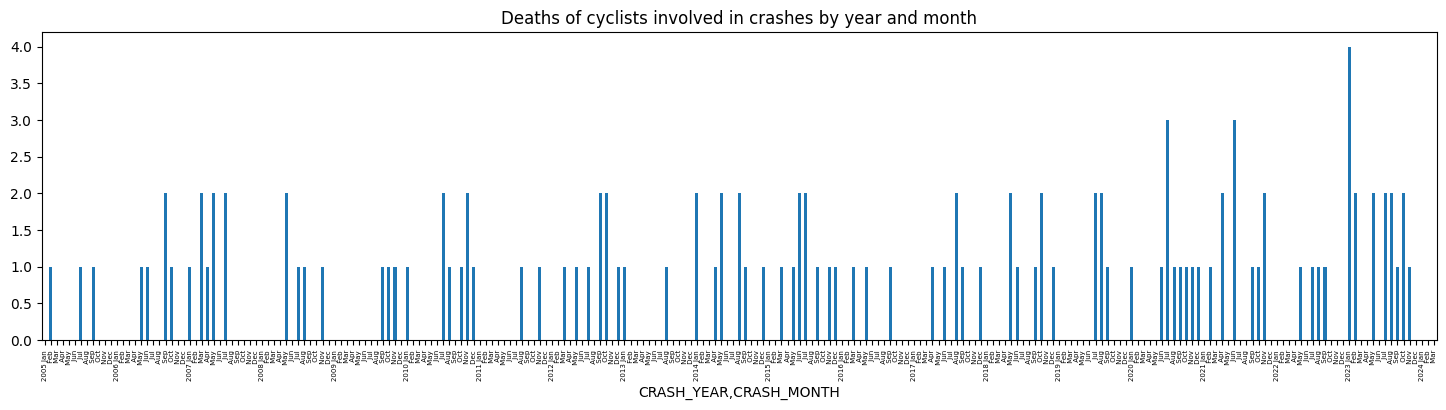

In [38]:
plt.figure(figsize=(18,4))
bike_crash = crash_data[crash_data['BICYCLE_COUNT']>0]
bcrash_plot=bike_crash.groupby(['CRASH_YEAR','CRASH_MONTH'])['FATAL_COUNT'].sum().plot(kind='bar', title='Deaths of cyclists involved in crashes by year and month')
bcrash_plot.set_xticklabels(format_xticklabels(bcrash_plot), fontsize=5)
plt.show()

* What is the distribution of fatalities across all types of incident?

In [39]:
crash_data['FATAL_COUNT'].value_counts()

FATAL_COUNT
0    685996
1      4825
2       207
3        33
4         8
Name: count, dtype: int64

* So there were 29 crashes where 2 people lost their lives.


* Searching for stories in data will involve exploring the data fulling using these kinds of queries and making observations on the results.


![](img/bike_crash.png)

* Here are various summaries of the incidents involving bicycles.

In [42]:
# How many bicycle related (cyclists?) deaths were there?

crash_data['BICYCLE_DEATH_COUNT'].value_counts()

BICYCLE_DEATH_COUNT
0    690948
1       121
Name: count, dtype: int64

In [43]:
# How many incidents where there where there was major injury of a cyclist?

crash_data['BICYCLE_SUSP_SERIOUS_INJ_COUNT'].value_counts()

BICYCLE_SUSP_SERIOUS_INJ_COUNT
0    690507
1       555
2         6
3         1
Name: count, dtype: int64

In [44]:
# To give proper context to the bicycle deaths look at the number of incidents
# where a bicycle was involved

crash_data[crash_data['BICYCLE_COUNT']>0]['BICYCLE_DEATH_COUNT'].value_counts()

BICYCLE_DEATH_COUNT
0    11606
1      121
Name: count, dtype: int64

In [45]:
# The same context for 

crash_data[crash_data['BICYCLE_COUNT']>0]['BICYCLE_SUSP_SERIOUS_INJ_COUNT'].value_counts()

BICYCLE_SUSP_SERIOUS_INJ_COUNT
0    11165
1      555
2        6
3        1
Name: count, dtype: int64

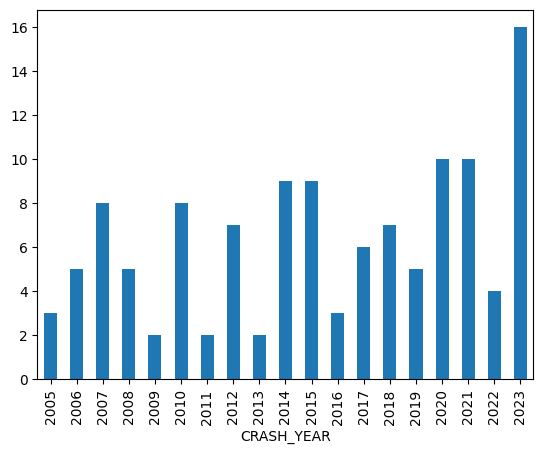

In [46]:
# filter for biycle death count
bicycle_death_filter = crash_data['BICYCLE_DEATH_COUNT']>0

# filter for serious bike injury
bicycle_serious_injury_filter = crash_data['BICYCLE_SUSP_SERIOUS_INJ_COUNT']>0

crash_data[bicycle_death_filter].groupby('CRASH_YEAR')['BICYCLE_DEATH_COUNT'].sum().plot(kind='bar')
plt.show()

In [47]:
bicycle_injuries = crash_data[bicycle_death_filter | bicycle_serious_injury_filter ]

In [48]:
bike_death_and_injury = bicycle_injuries.groupby('CRASH_YEAR')[['BICYCLE_DEATH_COUNT', 'BICYCLE_SUSP_SERIOUS_INJ_COUNT']].sum()
    
bike_death_and_injury

,BICYCLE_DEATH_COUNT,BICYCLE_SUSP_SERIOUS_INJ_COUNT
CRASH_YEAR,,
2005,3,21
2006,5,30
2007,8,35
2008,5,29
2009,2,32
2010,8,31
2011,2,25
2012,7,20
2013,2,33


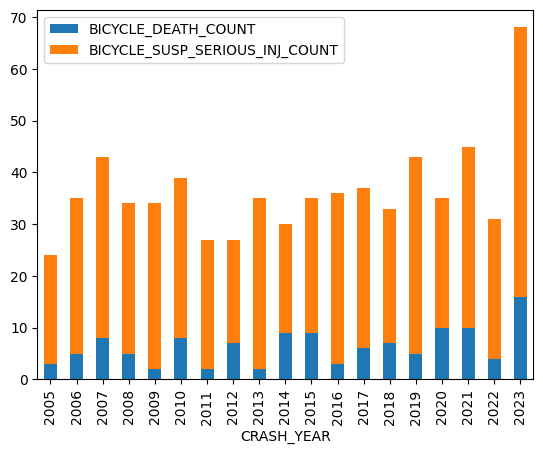

In [49]:
bike_death_and_injury.plot(stacked=True, kind='bar')
plt.show()

In [50]:
# filter for pedestrian accidents
ped_involved_filter = crash_data['PED_COUNT']>0

ped_accidents = crash_data[ped_involved_filter]
ped_accident_count = ped_accidents.groupby('CRASH_YEAR')[['PED_DEATH_COUNT', 'PED_SUSP_SERIOUS_INJ_COUNT']].sum()
    
ped_accident_count

,PED_DEATH_COUNT,PED_SUSP_SERIOUS_INJ_COUNT
CRASH_YEAR,,
2005,53,135
2006,66,141
2007,62,138
2008,51,126
2009,63,132
2010,46,149
2011,63,141
2012,66,137
2013,60,130


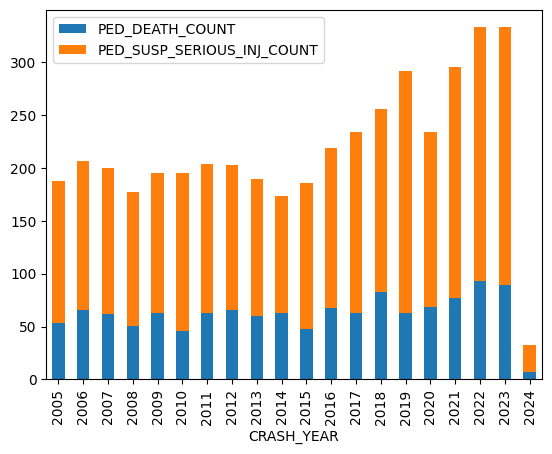

In [51]:
ped_accident_count.plot(stacked=True, kind='bar')
plt.show()

In [52]:
data_dictionary

,Column_Name,Description,Type,Length,Constraints
0,ARRIVAL_TM,Time police arrived at the scene,TEXT,4.0,HHMM
1,AUTOMOBILE_COUNT,Total amount of Automobiles Involved,NUMBER,2.0,NaN
2,BELTED_DEATH_COUNT,Total Deaths of belted occupants,NUMBER,2.0,NaN
3,BELTED_SUSP_SERIOUS_INJ_COUNT,Total Suspected Serious Injuries of belted occ...,NUMBER,2.0,NaN
4,BICYCLE_COUNT,Total amount of Bicycles involved,NUMBER,2.0,NaN
...,...,...,...,...,...
94,WZ_LN_CLOSURE,Did Work zone have a lane closure?,TEXT,1.0,"1=Y, 0 = N"
95,WZ_MOVING,Was there moving work in the zone?,TEXT,1.0,"1=Y, 0 = N"
96,WZ_OTHER,Was this a special type of work zone?,TEXT,1.0,"1=Y, 0 = N"
97,WZ_SHLDER_MDN,Was a median/shoulder in the zone?,TEXT,1.0,"1=Y, 0 = N"


### Geolocation

* There are two variables in the data set that recorded the geospatial position of the recorded crash incident:
  - `DEC_LATITUDE`
  - `DEC_LONGITUDE`

In [53]:
data_dictionary.set_index('Column_Name').loc[['DEC_LATITUDE', 'DEC_LONGITUDE']]

,Description,Type,Length,Constraints
Column_Name,,,,
DEC_LATITUDE,Decimal format of the Latitude,NUMBER,2.4,Latitude expressed in decimal degrees 99.9999
DEC_LONGITUDE,Decimal format of the Longitude,NUMBER,2.4,Longitude expressed in decimal degrees 99.9999


In [54]:
bicycle_injuries[['DEC_LATITUDE', 'DEC_LONGITUDE']]

,DEC_LATITUDE,DEC_LONGITUDE
1056,39.964656,-75.236198
5222,NaN,NaN
7065,39.867225,-75.377383
9223,39.923399,-75.299797
10257,40.196944,-75.115000
...,...,...
659242,39.981154,-75.831219
659576,40.149948,-75.230230
660165,39.981650,-75.283684
660582,39.829778,-75.393865


* If we plot these as a scatter plot you get an idea of how the data might be used to look for geospatial patterns

#### bicycle_injuries.plot(x='DEC_LATITUDE', y='DEC_LONGITUDE', kind='scatter')
plt.show()

#### Using a base layer

* Various `geojson` files are available that define shapes for regions like *states*, *counties*, *zip codes*, *census tracts*, etc.

In [56]:
philly_gdf = gpd.read_file('data/philadelphia_zip_boundaries.geojson')

<Axes: >

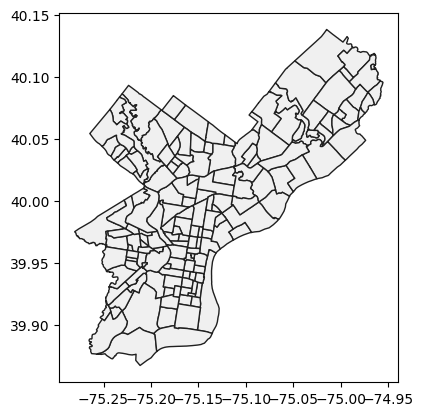

In [57]:
philly_gdf.plot(color='#F0F0F0', edgecolor='#202020')
#plt.show()

#### Converting a `pandas` data frame to a `geopandas` data frame
* But to make the best use of geolocation variables like `DEC_LATITUDE` and `DEC_LONGITUDE`, we need to translate them into a `geometry` data type.

In [58]:
geom=gpd.points_from_xy(bicycle_injuries['DEC_LONGITUDE'],
                  bicycle_injuries['DEC_LATITUDE']
                  )

bicycle_injuries_gdf=gpd.GeoDataFrame(bicycle_injuries, geometry=geom)

* Then we can combine both the base layer map and the points

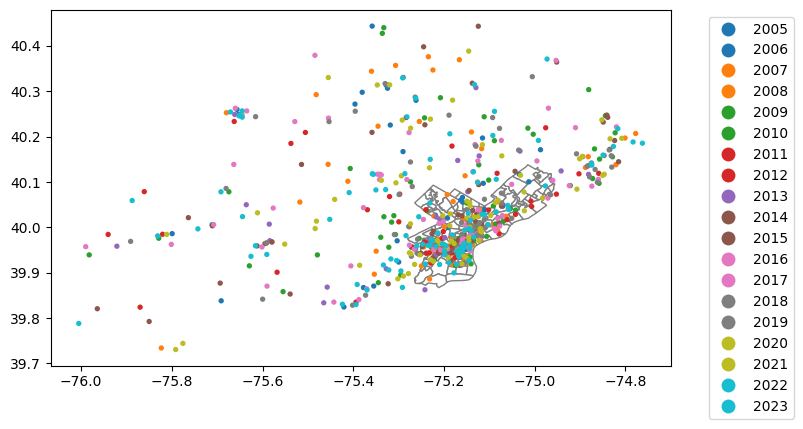

In [59]:
base=philly_gdf.plot(color='white', 
                     edgecolor='gray', figsize=(8,8))

bicycle_injuries_gdf.plot(ax=base, 
                          markersize=8, 
                          column='CRASH_YEAR', 
                          categorical=True, 
                          legend=True,
                          legend_kwds={'bbox_to_anchor': (1.05, 1), 'loc': 'upper left'}
                         )

plt.show()

* Here we notice that we have a Philadelphia city map but data from DISTRICT 6 for the crash data.
* So we want to filter using `COUNTY` and value 67



In [60]:
phil_city_filter = bicycle_injuries_gdf['COUNTY']==67

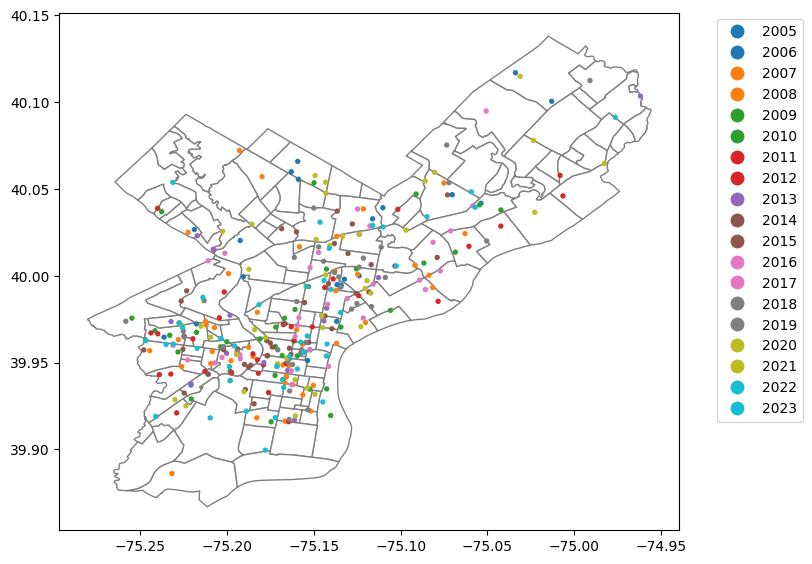

In [61]:
base=philly_gdf.plot(color='white', 
                     edgecolor='gray', figsize=(8,8))

bicycle_injuries_gdf[phil_city_filter].plot(ax=base, 
                          markersize=8, 
                          column='CRASH_YEAR', 
                          categorical=True, 
                          legend=True,
                          legend_kwds={'bbox_to_anchor': (1.05, 1), 'loc': 'upper left'}
                         )

plt.show()

### Aggregating crash incidents by geospatial regions

* The point data shown above (and the categorical labels by color) are difficult make much sense of
* One of the powerful things you can do with `geopandas` is to aggregate data using the available geometry.
* This means you can do the equivalent of a **GROUP BY** operation using geolocation, e.g.
  - count the number of bicycle crash incidents by the zip code they occurred in

In [62]:
# filter bike injuries for just city and set CRS for geometry

phil_bicycle_injuries_gdf=bicycle_injuries_gdf[phil_city_filter].set_crs('EPSG:4326')

#### Spatial Joins

* A **SPATIAL JOIN** (`.sjoin`) allows you merge two geodataframes using a common spatial shape.
* Here we want to use the boundaries of zip codes to group together the latitude and longitude points for the crash incidents.

In [63]:
bgdf=gpd.sjoin(philly_gdf, phil_bicycle_injuries_gdf)

* This will give us a ZIP CODE reference for each incident
* But we actually want to count up the number of incidents per area
* To do this we use `.dissolve` function

In [64]:
bgdf2=bgdf.dissolve(by='listname', aggfunc='count')

bgdf2.sort_values('DISTRICT', ascending=False)[['geometry','name']].head()

,geometry,name
listname,,
University City,"POLYGON ((-75.17935 39.95822, -75.17935 39.957...",18
Logan Square,"POLYGON ((-75.1759 39.96418, -75.17444 39.9640...",12
Rittenhouse,"POLYGON ((-75.16876 39.94404, -75.17033 39.944...",11
Hunting Park,"POLYGON ((-75.12598 40.01386, -75.12234 40.013...",9
Haddington,"POLYGON ((-75.22457 39.96492, -75.22421 39.963...",9


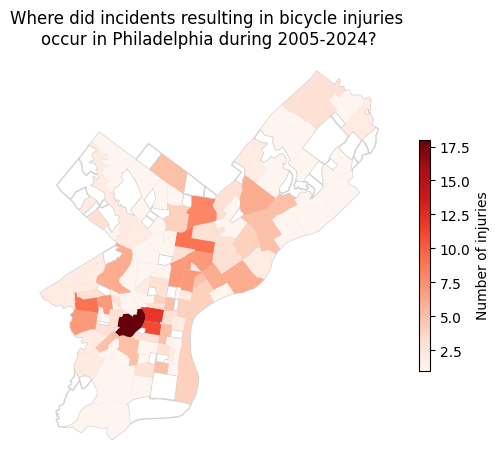

In [65]:
fig=philly_gdf.plot(color='white', 
                     edgecolor='lightgray', figsize=(6,6))

bgdf2.plot(ax=fig,column='name', cmap='Reds', 
           legend=True,
           legend_kwds={'shrink': 0.5, 
                        'label': 'Number of injuries'}     
          )
fig.axis('off')
fig.set_title('Where did incidents resulting in bicycle injuries \noccur in Philadelphia during 2005-2024?')

plt.show()


---

## Some (old) resources for use in looking for stories in these data

### News and other sites

* https://www.phillytrib.com/news/local_news/philly-s-riskiest-deadliest-roads-in-black-and-brown-neighborhoods/article_1d03b88e-2edf-5cbd-9f42-dd5eddf8fedf.html

* https://usa.streetsblog.org/2018/02/12/philadelphias-boulevard-of-death/

* https://billypenn.com/2017/02/06/how-roosevelt-boulevard-became-the-most-dangerous-road-in-philadelphia/

* KnowPA - infoviz example dashboards - http://www.knowpa.com/

### Legal firms citing crash data


> Roosevelt Boulevard, Philadelphia, Pennsylvania
> 
> While the other roads mentioned on this list are highways, Roosevelt Boulevard in Philadelphia is included because of its notoriety as one of the most dangerous thoroughfares in America. The boulevard consists of six 12-foot wide lanes in each direction, and drivers regularly exceed the posted 45 miles per hour and take the road’s dangerous curves far too fast. The boulevard also has two of the nation’s most dangerous intersections, where confused drivers frequently turn into the wrong three-lane stretch of traffic.

https://www.hg.org/legal-articles/5-of-the-most-dangerous-roads-in-the-u-s--32057

> Pennsylvania roads are dangerous, and with its large concentration of population, Philadelphia has the greatest number of crash-related deaths. In fact, according to PennDOT data on fatal car accidents, Philadelphia had more than a quarter of the road segments that were among the state’s most deadly from 2015-2017. During this period, Philly had 24 road segments with 155 total fatal collisions, leading to 167 deaths. This amounted to about a third of the segments with at least four deaths in the entire state.

https://www.wnwlaw.com/philly-four-pennsylvanias-ten-deadliest-roads/


* Study by law firm

https://www.dallashartman.com/blog/2019/01/deadly-roads-pa/